In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import kagglehub
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Download dataset using KaggleHub (Kaggle API wrapper)
import os


path = kagglehub.dataset_download("shwetabh123/mall-customers")

print("Dataset downloaded to:", path)

# Load dataset
df = pd.read_csv(os.path.join(path, "Mall_Customers.csv"))

print("Dataset Shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nDataset Description:")
print(df.describe())

Dataset downloaded to: C:\Users\madha\.cache\kagglehub\datasets\shwetabh123\mall-customers\versions\1
Dataset Shape: (200, 5)

First 5 rows:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4

In [5]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate Rows: 0


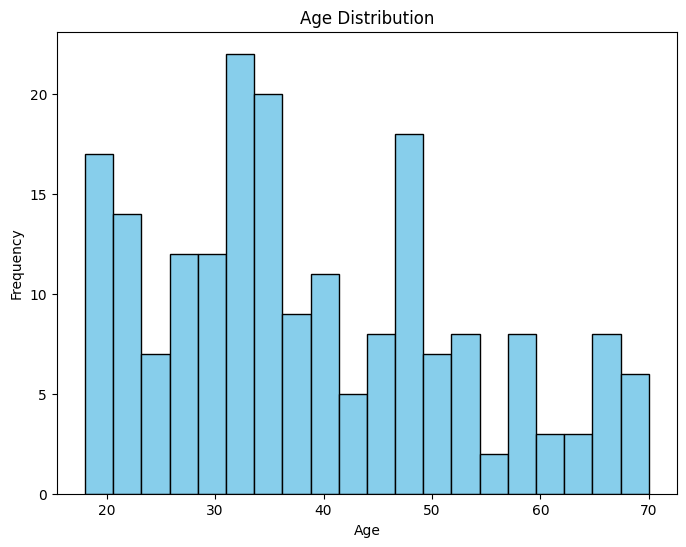

In [6]:
plt.figure(figsize=(8,6))
plt.hist(df['Age'], bins=20, color='skyblue', edgecolor='black')

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

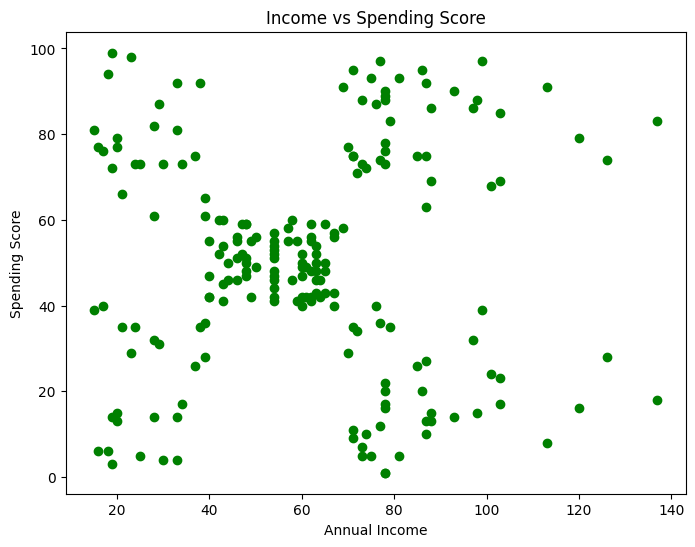

In [7]:
plt.figure(figsize=(8,6))

plt.scatter(df['Annual Income (k$)'],
            df['Spending Score (1-100)'],
            color='green')

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Income vs Spending Score")

plt.show()

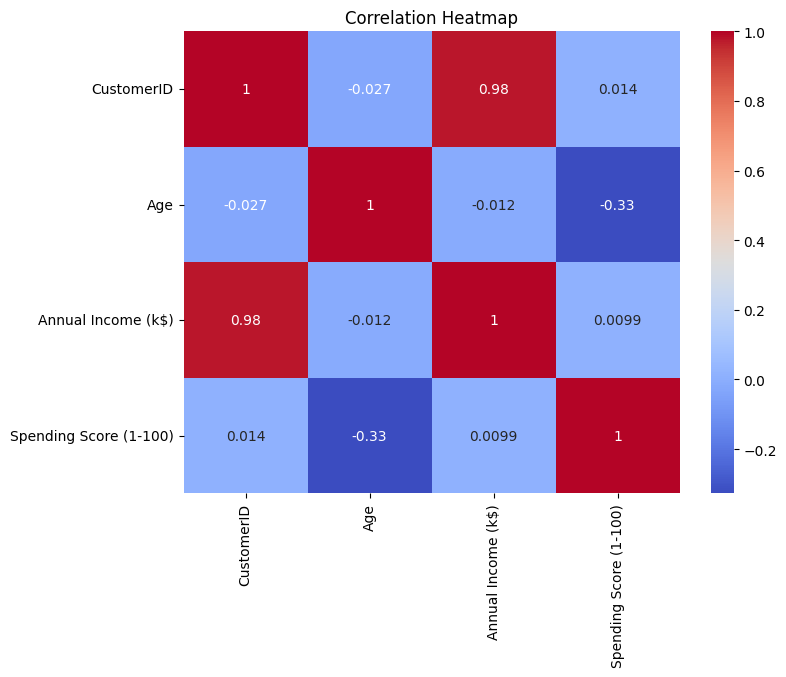

In [8]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [9]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

print("Feature Shape:", X.shape)
print("\nFeatures Used:")
print(X.head())

Feature Shape: (200, 2)

Features Used:
   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Data Sample:")
print(X_scaled[:5])

Scaled Data Sample:
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


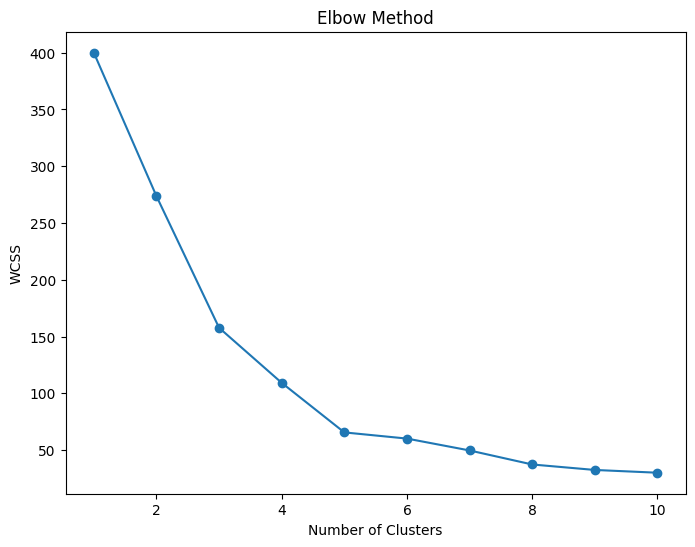

In [11]:
wcss = []

for i in range(1,11):
    
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,6))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [12]:
kmeans_model = KMeans(n_clusters=5, random_state=42)

clusters = kmeans_model.fit_predict(X_scaled)

df['Cluster'] = clusters

print("Cluster Centers:")
print(kmeans_model.cluster_centers_)

Cluster Centers:
[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


In [13]:
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.5546571631111091


In [14]:
print("Cluster Counts:")
print(df['Cluster'].value_counts())

Cluster Counts:
Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


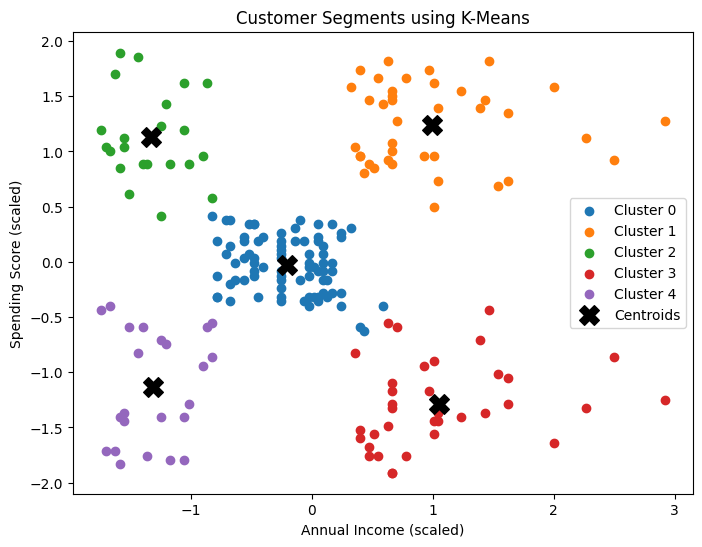

In [15]:
plt.figure(figsize=(8,6))

for i in range(5):
    
    plt.scatter(
        X_scaled[clusters == i, 0],
        X_scaled[clusters == i, 1],
        label=f'Cluster {i}'
    )

plt.scatter(
    kmeans_model.cluster_centers_[:,0],
    kmeans_model.cluster_centers_[:,1],
    s=200,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title("Customer Segments using K-Means")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")

plt.legend()

plt.show()

In [16]:
cluster_summary = df.groupby('Cluster')[['Age','Annual Income (k$)','Spending Score (1-100)']].mean()

print("Cluster Summary:")
print(cluster_summary)

Cluster Summary:
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        25.272727           25.727273               79.363636
3        41.114286           88.200000               17.114286
4        45.217391           26.304348               20.913043
